In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from eval_genome import generate_configs, fitness_single
from util import test_mp

## Controller per 'n' defender

In [31]:
# Load best controller found for each 'n' by CMA-ES
best_each_n = pd.read_json("best_of_each_n.json", orient="columns")

<BarContainer object of 40 artists>

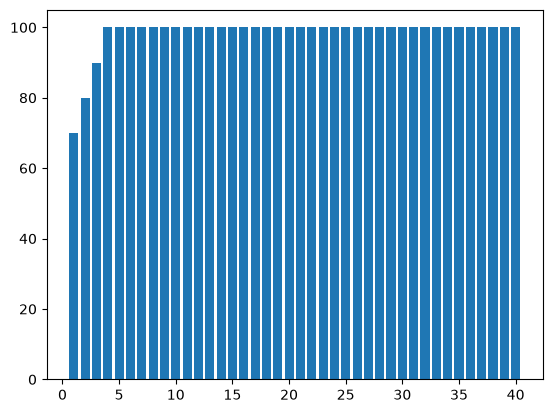

In [32]:
# Plot best data
x, y = best_each_n["n"], best_each_n["fitness"] * -100
plt.bar(x, y)

# Analysis of controller over 'n'

In [33]:
seed, trials = 32, 100
n_range = [*range(3, 15+1)]

def test_genome_over_n(genome) -> list[float]:
    success_trajectory = []
    for n in n_range:
        _, rate = test_mp(generate_configs(
            genome, rng_seed=seed, n=n, trials=trials),
            fitness_single,
        )
        success_trajectory.append(rate)

    return success_trajectory

control_of = [4, 5, 6, 7, 8, 10, 15]
genomes = best_each_n[best_each_n["n"].isin(control_of)]["unnorm_genome"].tolist()

results = {}
for n, genome in zip(control_of, genomes):
    results[f"c{n}"] = test_genome_over_n(genome)

100%|██████████| 100/100 [00:25<00:00,  3.90it/s]


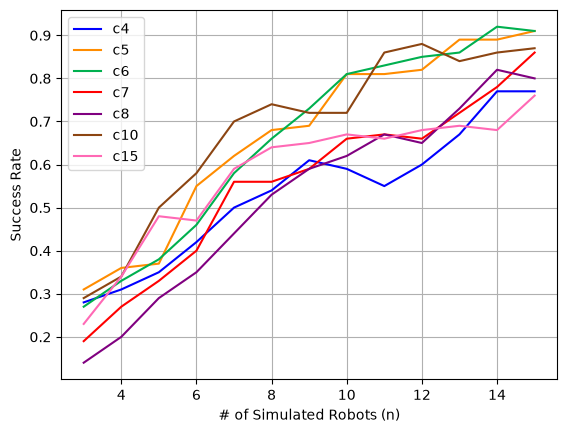

In [45]:
line_colors = [
    (0.0, 0.0, 1.0),   # Blue
    (1.0, 0.55, 0.0),  # Orange
    (0.0, 0.69, 0.31), # Green
    (1.0, 0.0, 0.0),   # Red
    (0.5, 0.0, 0.5),   # Purple
    (0.55, 0.27, 0.07),# Brown
    (1.0, 0.41, 0.71)  # Pink
]

plt.xlabel("# of Simulated Robots (n)")
plt.ylabel("Success Rate")
plt.grid()
for cn, lclr in zip(control_of, line_colors):
    key = f"c{cn}"
    plt.plot(n_range, results[key], color=lclr, label=key)

plt.legend(loc="best")
plt.show()